# TP 3 : 3D pose computation

Please upload in time your completed notebook, including your answers and illustrations. You may need to add cells to write your code and comments.


## 1. Getting started

Include the libraries we need and get the Hsterix1.png and Hsterix2.png images or download them directly with Colab:

In [1]:
import cv2 # OpenCV
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# To see the images in a notebook:
%matplotlib inline

In [2]:
#!wget "http://imagine.enpc.fr/~lepetitv/triva/Hsterix1.png"
#!wget "http://imagine.enpc.fr/~lepetitv/triva/Hsterix2.png"
#!wget "http://imagine.enpc.fr/~lepetitv/triva/Hsterix1_box.png"
#!ls

# With or without Colab, then:
img = plt.imread('Hsterix1.png')
I1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = plt.imread('Hsterix2.png')
I2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Visualizing the images...

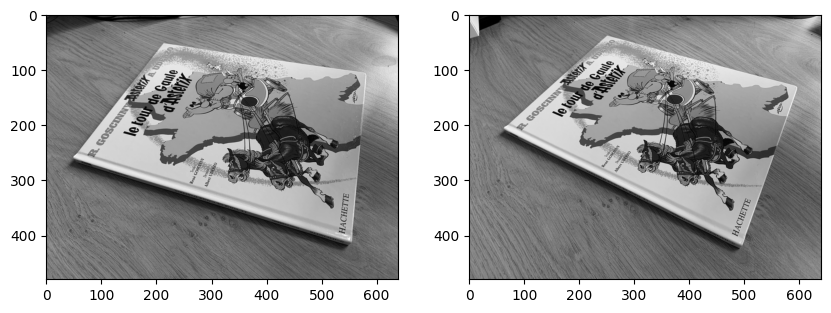

In [3]:
figsize = 5
fig = plt.figure(figsize=(2*figsize,figsize))
fig.add_subplot(1, 2, 1)
plt.imshow(I1, cmap='gray')
fig.add_subplot(1, 2, 2)
plt.imshow(I2, cmap='gray')
plt.show()

## 2 Computing a homography

The size of the comic book is 22.5cm x 29.5cm.  The reprojections of its corners in image Hsterix1.png are:
```
UV2 = [[50,258], [213,52], [580,107], [554,412]]
```

Compute the homography between points on the book cover and their reprojections in image Hsterix1.png. The origin of the coordinate system for the book cover should be at its top-left corner, its X axis along the top edge (pointing to the right), its Y axis along the left edge (pointing to the bottom).

Store the result in a 3x3 numpy array `H`.

Hint:
```
  (U, S, Vt) = np.linalg.svd(M)
  print(S)
```



In [4]:
UV2 = [[50,258], [213,52], [580,107], [554,412]]   # projections dans I1
UV1 = [[0,0], [22.5, 0], [22.5, 29.5], [0, 29.5]] # coins du livre en cm

def compute_homography(pts_src, pts_dst):
    """
    Calcule H telle que pts_dst ~ H @ pts_src
    pts_src (points sources) : coordonnées livre (cm)
    pts_dst (points destination) : coordonnées image (pixels)
    """
    N = len(pts_src)
    # chaque correspondance donne 2 lignes dans M, et H a 
    # 9 coefficients donc M est 2Nx9
    M = np.zeros((2 * N, 9))
    for i in range(N):
        x, y   = pts_src[i]
        u, v   = pts_dst[i]
        # on écrit les deux équations issues de (u,v) ~ H*(x,y,1)
        # en développant le produit croisé et en mettant tout à gauche
        M[2*i]     = [-x, -y, -1,  0,  0,  0, u*x, u*y, u]
        M[2*i + 1] = [ 0,  0,  0, -x, -y, -1, v*x, v*y, v]
    # on résout Mh=0 par SVD : la solution est le vecteur propre associé
    # à la plus petite valeur singulière
    (U, S, Vt) = np.linalg.svd(M)
    print("Valeurs Singulières:", S)
    # la dernière ligne de Vt correspond à la plus petite valeur 
    # singulière
    h = Vt[-1] 
    H = h.reshape(3, 3)
    return H

H = compute_homography(UV1, UV2)
print("H =\n", H)



Valeurs Singulières: [2.83980575e+04 1.05995884e+04 3.28353833e+02 4.54818307e+01
 2.53601941e+01 1.01279193e+01 7.59330163e+00 9.96172026e-01]
H =
 [[-4.15584477e-02 -4.67414485e-02 -1.89787296e-01]
 [ 3.13195822e-02 -6.34855144e-03 -9.79302446e-01]
 [-6.60111608e-05  3.26857498e-05 -3.79574592e-03]]


### Visualizing the results

The code below will plot the border of the comic book in Hsterix1.png if your matrix `H` is correct.


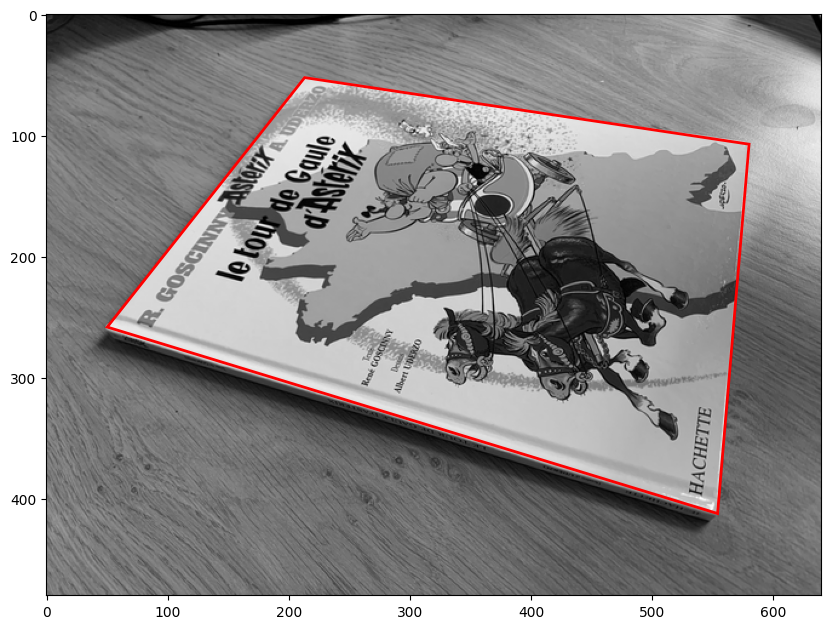

In [7]:
def show_Hpolygon(image, H, uv):
  fig, ax = plt.subplots(figsize=(10, 10))
  ax.imshow(image, cmap='gray')
  N = len(uv[:])
  uv2 = np.zeros((N,2))
  for i in range(N):
    a =  H[0][0] * uv[i][0] + H[0][1] * uv[i][1] + H[0][2]
    b =  H[1][0] * uv[i][0] + H[1][1] * uv[i][1] + H[1][2]
    c =  H[2][0] * uv[i][0] + H[2][1] * uv[i][1] + H[2][2]
    uv2[i][:] = [a/c, b/c]
  pt = patches.Polygon(uv2, closed = True, lw = 2, 
                       edgecolor = 'red', fill = False)
  ax.add_patch(pt)
  plt.show()

UV1 = [[0,0], [22.5, 0], [22.5, 29.5], [0, 29.5]]
show_Hpolygon(I1, H, UV1)

## 3 Augmented Reality

Let's assume that the matrix of internal parameters `K` is equal to:
```
K = np.array([
      [1000,    0, 320], 
      [   0, 1000, 240],
      [   0,    0,   1]])
```

Use `K` and `H` to draw a box on the comic book, as in the image below:

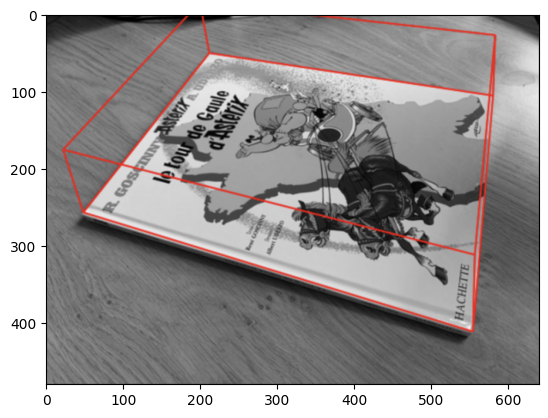

In [8]:
plt.imshow(plt.imread('Hsterix1_box.png'), cmap='gray')

Don't use an external library to plot the box, simply write your own function by using `show_Hpolygon` as an example.

Hints: What is the link between H, K, R, and T?   You can compute the third column of a rotation matrix from the two first columns

If you are lucky, the box will be as expected, but if not, the box will be "below" the book cover instead of being "above". Remember that `H` is defined up to a scale factor, so if `H` is a correct homography matrix, `-H` is also correct. Can you make your code plot the box "above" the cover for both `H` and `-H`?

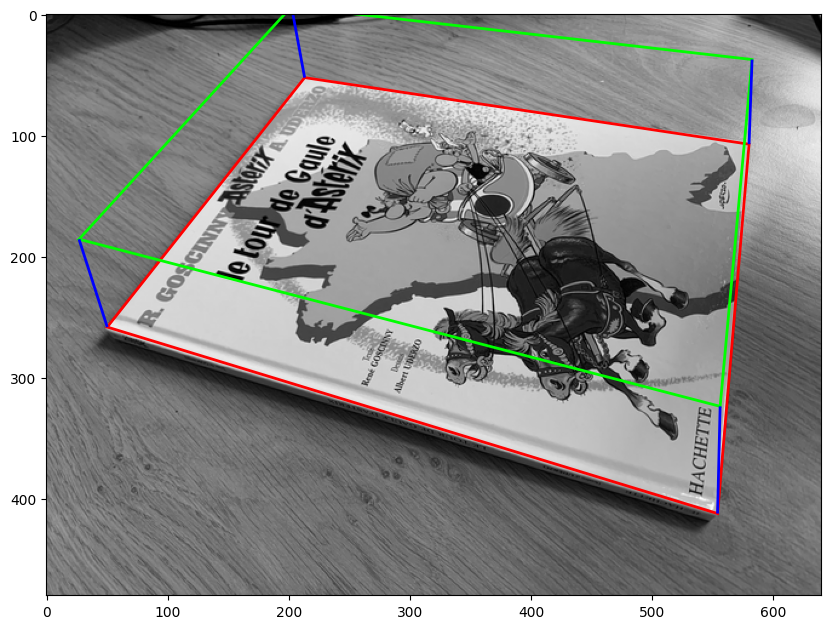

In [9]:
K = np.array([[1000,    0, 320],
              [   0, 1000, 240],
              [   0,    0,   1]], dtype=float)

def get_pose_from_H(H, K):
    #  on part de H = K @ [r1 | r2 | t],
    #  donc K^{-1} H = [r1 | r2 | t] à un facteur près
    KinvH = np.linalg.inv(K) @ H
    #on normalise avec la norme de r1 pour avoir un vrai vecteur unitaire
    lam = np.linalg.norm(KinvH[:, 0])
    r1 = KinvH[:, 0] / lam
    r2 = KinvH[:, 1] / lam
    t  = KinvH[:, 2] / lam

    # H est défini à un signe près, on force t[2]>0 pour que le livre 
    # soit devant la caméra comme ça ça marche aussi 
    # bien pour H que pour -H
    if t[2] < 0:
        r1, r2, t = -r1, -r2, -t
    # r3 se déduit de r1 et r2 car R doit être orthogonale 
    # (produit vectoriel)
    r3 = np.cross(r1, r2)
    R = np.column_stack([r1, r2, r3])
    return R, t


def show_3Dpolygon(ax, K, R, t, pts_3d, color='lime', lw=2):
    """
    Projette une liste de points 3D et dessine un polygone fermé.
    """
    N = len(pts_3d)
    uv2 = np.zeros((N, 2))
    for i in range(N):
        X, Y, Z = pts_3d[i]
        # on passe le point dans le repère caméra puis on projette avec K
        P_cam = R @ np.array([X, Y, Z]) + t
        uv_h  = K @ P_cam
        # division par la 3ème coordonnée pour repasser en pixels
        uv2[i] = [uv_h[0] / uv_h[2], uv_h[1] / uv_h[2]]
    pt = patches.Polygon(uv2, closed=True, lw=lw, 
                         edgecolor=color, fill=False)
    ax.add_patch(pt)


def draw_box(image, H, K, height=5.0):
    """
    Dessine une boîte 3D de hauteur `height` cm au-dessus du livre.
    Utilise show_3Dpolygon pour chaque face/arête.
    """
    R, t = get_pose_from_H(H, K)

    w, h = 22.5, 29.5
    # la base est dans le plan du livre (Z=0)
    # le sommet est à Z=-height : négatif car "au-dessus" 
    # c'est la direction opposée à la normale
    base = [(0,0,0),       (w,0,0),       (w,h,0),       (0,h,0)      ]
    top  = [(0,0,-height), (w,0,-height), (w,h,-height), (0,h,-height)]

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image, cmap='gray')

    show_3Dpolygon(ax, K, R, t, base, color='red')        # face du bas
    show_3Dpolygon(ax, K, R, t, top,  color='lime')       # face du haut
    for b, tp in zip(base, top):                       # arêtes verticales
        show_3Dpolygon(ax, K, R, t, [b, tp], color='blue')

    plt.show()

draw_box(I1, H, K, height=5.0)

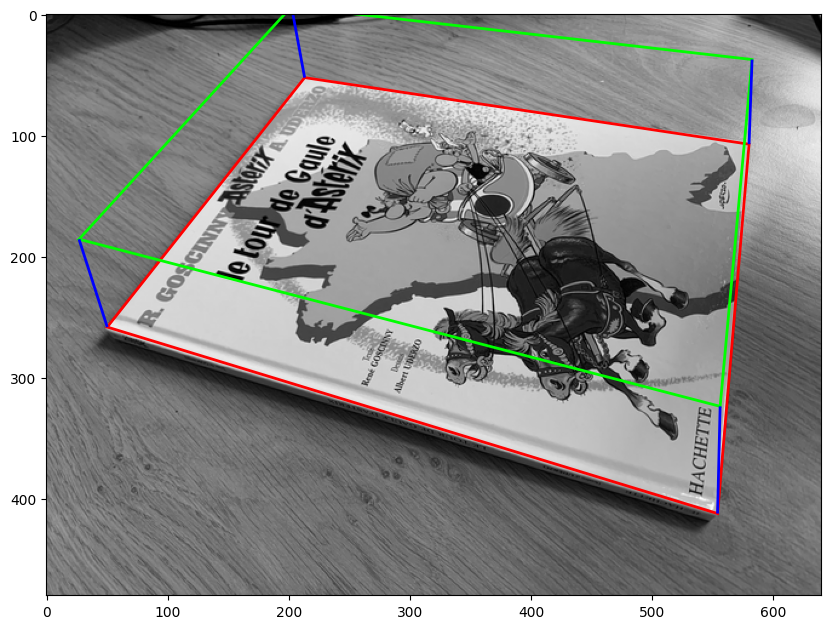

In [10]:
H = -H
draw_box(I1, H, K, height=5.0)



Tout fonctionne corrctement, la boite est bien au dessus pour les cas H et -H

## 4 3D tracking

Can you plot the box on the comic book in Hsterix2.png - of course without measuring the reprojections of the corners in this image?

Hint: What is the product of two homographies?

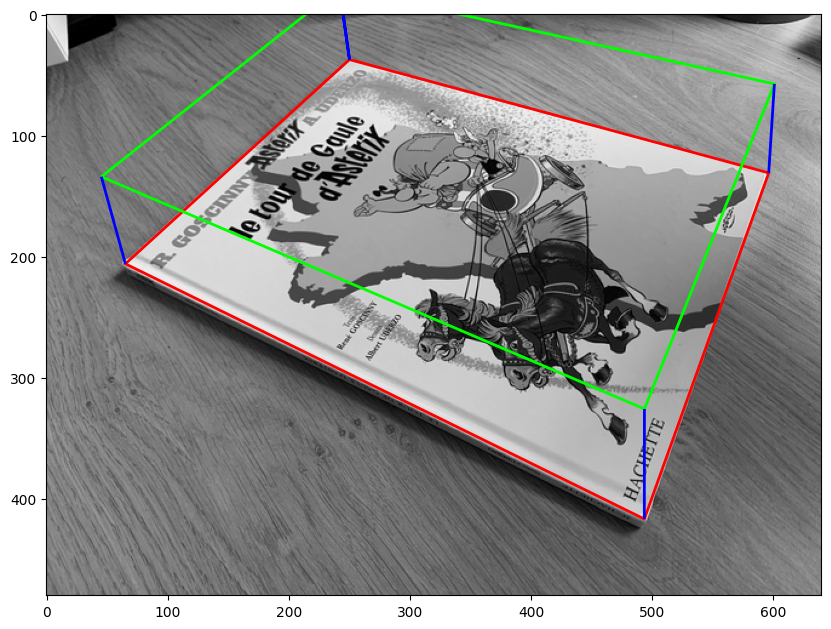

In [12]:
# idée : on cherche des correspondances entre I1 et I2 avec ORB
# ORB détecte des keypoints et calcule des descripteurs binaires 
# rapides à comparer
# j'utilise ORB plutôt que Harris car sur internet 
# ils mentionnait que orb fournissait des descripteurs 
detector = cv2.ORB_create(2000)
# on vérifie que les images sont en uint8 sinon ORB ne fonctionne pas
I1 = (I1 * 255).astype(np.uint8) if I1.dtype != np.uint8 else I1
I2 = (I2 * 255).astype(np.uint8) if I2.dtype != np.uint8 else I2
kp1, des1 = detector.detectAndCompute(I1, None)
kp2, des2 = detector.detectAndCompute(I2, None)
# on apparie les descripteurs avec la distance de Hamming 
# (adaptée aux descripteurs binaires)
# crossCheck=True garde seulement les meilleurs matchs 
# mutuels pour filtrer les faux positifs
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)

pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

# on estime H12 (I1→I2) avec RANSAC pour ignorer 
# les correspondances aberrantes (trouvé sur internet)
H12, _ = cv2.findHomography(pts1, pts2, cv2.RANSAC)


# composition des homographies :
# H   : livre → I1
# H12 : I1 → I2
# donc H2 = H12 @ H fait le chemin livre → I2 
# sans aucune mesure manuelle sur I2
H2 = H12 @ H

# dessiner la boîte sur I2
draw_box(I2, H2, K, height=5.0)


On obtient bien la box au dessus et elle est parfaitement adaptée 